## Measuring the HOG:

#### Parsing COCO to read annotations

In [1]:
# Load the autoreload extension
%load_ext autoreload

# Set autoreload to reload all modules before executing code
%autoreload 2

In [2]:
from pathlib import Path 
import os
import numpy as np

import pandas as pd 

from utils import *


imgs = list(Path('/Data_large/marine/Datasets/VDS2Raw/imgs').glob('*.tif'))
print('Listing the number of imgs:')
print(len(imgs))

train_coco_path = '/Data_large/marine/Datasets/VDS2Raw/annotations/train.json'
val_coco_path = '/Data_large/marine/Datasets/VDS2Raw/annotations/val.json'
test_coco_path = '/Data_large/marine/Datasets/VDS2Raw/annotations/test.json'

train_coco = get_coco(train_coco_path)
val_coco = get_coco(val_coco_path)
test_coco = get_coco(test_coco_path)

Listing the number of imgs:
389


In [3]:
annotations1 = train_coco['annotations']
annotations2 = val_coco['annotations']
annotations3 = test_coco['annotations']
annotations = annotations1 + annotations2 + annotations3

images_train = train_coco['images']
images_val = val_coco['images']
images_test = test_coco['images']
images = images_train + images_val + images_test

imgidToImage = {x['id']:x['file_name'] for x in images} # dict because this is unique assignment
NameToID = {x['id']:x['file_name'] for x in images}


def parser_annot(annotX):
    try:
        if isinstance(annotX['info'], list):
            annotX['info'] = annotX['info'][0]
        
        return annotX['info']['Ship type']
    except:
        return 'Unknown'

imgidAndBBox = [(x['image_id'],x['bbox']) for x in annotations] # list because assignment can be multiple
imgidAndBBoxAndType = [(x['image_id'],x['bbox'],parser_annot(x)) for x in annotations] # list because assignment can be multiple
imgidToBBox = convert_to_dict(imgidAndBBox)
filename_bbox = {imgidToImage[x]:y for x,y in imgidToBBox.items()}

nameToPaths = {x.name:x.as_posix() for x in imgs}
PathsToName = {x.as_posix():x.name for x in imgs}

### Creating npy files

In [4]:
base_outdir = '/Data_large/marine/PythonProjects/MMDET/studies/cropsSen'

for item in imgidAndBBoxAndType:
    name = imgidToImage[item[0]]
    stem = name.split('.')[0]
    path = nameToPaths[name]
    print(path, item[1], item[2])
    bbox = item[1]
    className = item[2]
    
    img = read_tif(file_path=path, band_indices=[1,2,3,4]) # selected band 1
    # 2. Crop Img using bbox info  3. Save crops in the folders
    stringaBox = str(bbox).replace(' ','').replace('[','').replace(']','').replace(',','_')
    
    for sel_band in [1,2,3,4]:
        output_dir = f'{base_outdir}/B{sel_band}/{stem}'
        os.makedirs(output_dir, exist_ok=True)
        x, y, width, height = bbox
        x, y, width, height = int(x), int(y), int(width), int(height)
        buffer = 30
        x, y, width, height = x-buffer//2, y-buffer//2, width+buffer, height+buffer
        
        
        cropped_array = img[0][sel_band]
        cropped_array = cropped_array[y:y+height, x:x+width]
        className = str(className).replace('/','_')
        output_path = f'{output_dir}/{stringaBox}___{className}.npy'
        np.save(output_path.replace(' ','_'), cropped_array)
        

/Data_large/marine/Datasets/VDS2Raw/imgs/day6_g_23_coreg.tif [637.9746835443037, 963.9240506329113, 12.658227848101319, 31.64556962025324] Tanker
/Data_large/marine/Datasets/VDS2Raw/imgs/day6_g_23_coreg.tif [1208.2278481012659, 941.1392405063291, 13.924050632911303, 41.77215189873414] Tanker
/Data_large/marine/Datasets/VDS2Raw/imgs/day4_g_54_coreg.tif [170.8759689922481, 173.9728682170542, 12.015503875968989, 28.294573643410843] Cargo
/Data_large/marine/Datasets/VDS2Raw/imgs/day4_g_54_coreg.tif [1363.5116279069766, 1541.0271317829456, 12.015503875968989, 15.891472868217079] Cargo
/Data_large/marine/Datasets/VDS2Raw/imgs/day2_g_10_coreg.tif [244.96644295302013, 715.0302013422819, 9.731543624161077, 13.42281879194627] Fishing
/Data_large/marine/Datasets/VDS2Raw/imgs/day2_g_10_coreg.tif [1052.6845637583892, 915.7013422818792, 25.503355704697924, 14.765100671140885] Tanker
/Data_large/marine/Datasets/VDS2Raw/imgs/day1_g_21_coreg.tif [863.4603174603175, 1054.7380952380954, 21.82539682539686

In [4]:
classTranslator = {
    'Bulk Carrier': 'Bulk Carrier',
    'Cement Carrier': 'Bulk Carrier',
    'Heavy Load Carrier': 'Bulk Carrier',

    'General Cargo': 'General Cargo',
    'Cargo': 'General Cargo',

    'Container Ship': 'Container Ships',
    'Vehicles Carrier': 'Container Ships',

    'Tanker': 'Tanker',
    'Tanker - Hazard A (Major)': 'Tanker',
    'Tanker - Hazard C (Minor)': 'Tanker',
    'Tanker - Hazard D (Recognizable)': 'Tanker',
    'Chemical Tanker': 'Tanker',
    'Oil Products Tanker': 'Tanker',
    'Oil': 'Tanker',

    'Other': 'Other',
    'Dredger': 'Other',
    'Fishing': 'Other',
    'Reefer': 'Other',
    'Hopper Dredger': 'Other',
    'Offshore Supply Ship': 'Other',
    'Livestock Carrier': 'Other'
}

#### Helper to list files:

In [5]:
B = {i+1:get_corresponding_B1_files(i+1) for i in range(4)}

### Show vessel in a single band:

265
Number of HOG features with threshold 0.7: 265


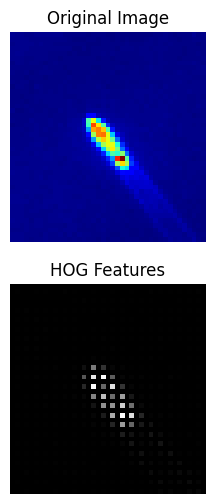

In [6]:
array_in_band = {}
for sel_band in range(1,5,1):
    image_array = np.load(B[sel_band][17])
    array_in_band[sel_band] = image_array

# Set the threshold value
threshold_value = 0.7

BAND = 4
input_img = array_in_band[BAND]


hog_image, num_features = get_hog_and_features(array_in_band[3], threshold_value)

print(num_features)
# plt.imshow(hog_image, cmap='jet')
# plt.imshow(input_img, cmap='jet')
# plt.colorbar(label='Uncalibrated Pixel Intensity')

print(f"Number of HOG features with threshold {threshold_value}: {num_features}")
visualize_hog(image_array, threshold=threshold_value)

#### 4 Bands View:

In [11]:
def plot_bands_and_hog(array_in_band, threshold_value=0.85, max_bands=4, titles=None):
    """
    Plot original images and their HOG (Histogram of Oriented Gradients) features for each band in a 2-row layout.
    Utilizes Seaborn for enhanced aesthetics.

    Parameters:
    array_in_band (dict): Dictionary where keys are band indices (1-12) and values are 2D numpy arrays representing images.
    threshold_value (float): Minimum intensity threshold for HOG features, defaults to 0.85.

    Returns:
    None: The function displays a plot with the original images and their corresponding HOG features.
    """


    # Create a 2-row subplot layout
    fig, axes = plt.subplots(2, max_bands, figsize=(20, 2), sharex=True, sharey=True, dpi=300)
    
    for band in range(1, max_bands+1):
        # Get the image and its corresponding HOG features
        image_array = array_in_band[band]
        hog_image, num_features = get_hog_and_features(image_array, threshold_value)
        
        # Plot the original image in the first row
        axes[0, band-1].imshow(image_array, cmap='jet')
        axes[0, band-1].axis('off')
        if titles is not None:
            axes[0, band-1].set_title(f'Band {titles[band-1]}', fontsize=10, fontweight='bold')
        else:
            axes[0, band-1].set_title(f'Band {band}', fontsize=10, fontweight='bold')
        
        # Plot the HOG features in the second row
        axes[1, band-1].imshow(hog_image, cmap='gray')
        axes[1, band-1].axis('off')
        axes[1, band-1].set_title(f'N. feats: ({num_features})', fontsize=9, fontweight='bold')
    
    # Adjust layout and spacing
    plt.subplots_adjust(wspace=0.2, hspace=0.6)
    plt.show()

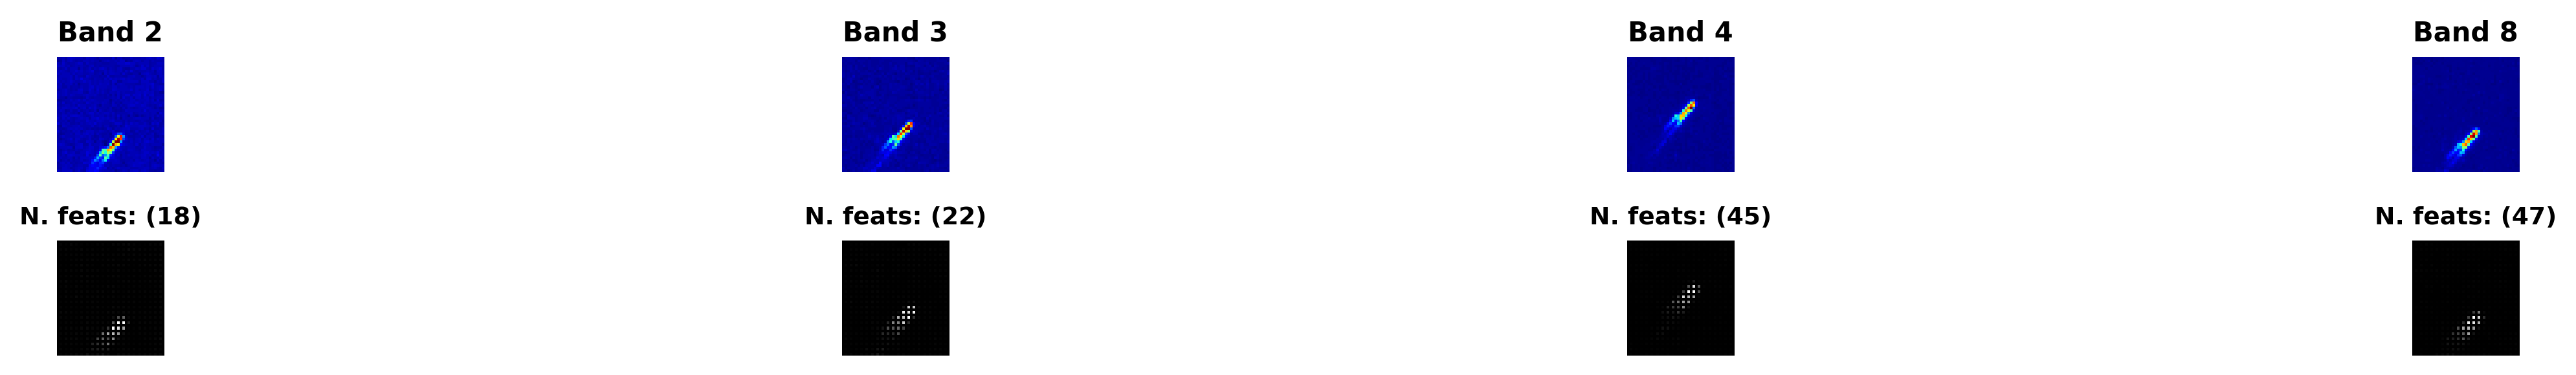

In [15]:
img_id = 24

# Assuming array_in_band is already populated with images for bands 1 to 12
array_in_band = {}
for sel_band in range(1,5,1):
    image_array = np.load(B[sel_band][img_id])
    array_in_band[sel_band] = image_array
    
# Set the threshold value
threshold_value = 0.8

# Plot all bands and their HOG features
plot_bands_and_hog(array_in_band, threshold_value, max_bands=4, titles=['2', '3', '4', '8'])

#### Computating Hog Features for All:

In [10]:
def process_images(B, threshold_value=0.75):
    """
    Process images to compute HOG features for multiple bands.

    Parameters:
    B (dict): A dictionary where the keys are band numbers (1 to 12) and the values are lists of file paths.

    Returns:
    tuple: Two dictionaries:
        - band_num_hog: A dictionary where keys are band numbers (1 to 12) and values are lists of HOG feature counts.
        - stemToHog: A dictionary where keys are file stems and values are HOG feature counts.
    """
    
    band_num_hog = {i: [] for i in range(1, 5)}
    stemToHog = {}

    for i in tqdm(range(695), desc="Processing images"):
        for sel_band in range(1, 5):
            filename = B[sel_band][i]
            try:
                image_array = np.load(filename)
                num_features = count_hog_features(image_array, threshold_value)
            except Exception as e:
                print(f"Error processing {filename}: {e}")
                continue
            
            band_num_hog[sel_band].append(num_features)
            
            stem = Path(filename).stem
            stemToHog[stem] = num_features
            
    return band_num_hog, stemToHog

In [11]:
for threshold_value in [0.6, 0.7, 0.8]:
    band_num_hog, stemToHog = process_images(B, threshold_value)
    pd.to_pickle(band_num_hog, f'sen_hog_results/band_num_hog_{threshold_value}.pkl')
    pd.to_pickle(stemToHog, f'sen_hog_results/stemToHog_{threshold_value}.pkl')

Processing images:  25%|██▌       | 177/695 [01:15<03:36,  2.39it/s]

Error processing /Data_large/marine/PythonProjects/MMDET/studies/cropsSen/B1/day5_g_19_coreg/1934.1772151898733_10.759493670886075_18.354430379746873_13.29113924050633___Cargo.npy: index 0 is out of bounds for axis 0 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/cropsSen/B2/day5_g_19_coreg/1934.1772151898733_10.759493670886075_18.354430379746873_13.29113924050633___Cargo.npy: index 0 is out of bounds for axis 0 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/cropsSen/B3/day5_g_19_coreg/1934.1772151898733_10.759493670886075_18.354430379746873_13.29113924050633___Cargo.npy: index 0 is out of bounds for axis 0 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/cropsSen/B4/day5_g_19_coreg/1934.1772151898733_10.759493670886075_18.354430379746873_13.29113924050633___Cargo.npy: index 0 is out of bounds for axis 0 with size 0


Processing images:  61%|██████    | 421/695 [03:15<01:16,  3.57it/s]

Error processing /Data_large/marine/PythonProjects/MMDET/studies/cropsSen/B1/day3_g_10_coreg/1054.7142857142858_6.349206349206349_13.888888888888914_15.873015873015873___Unknown.npy: index 0 is out of bounds for axis 0 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/cropsSen/B2/day3_g_10_coreg/1054.7142857142858_6.349206349206349_13.888888888888914_15.873015873015873___Unknown.npy: index 0 is out of bounds for axis 0 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/cropsSen/B3/day3_g_10_coreg/1054.7142857142858_6.349206349206349_13.888888888888914_15.873015873015873___Unknown.npy: index 0 is out of bounds for axis 0 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/cropsSen/B4/day3_g_10_coreg/1054.7142857142858_6.349206349206349_13.888888888888914_15.873015873015873___Unknown.npy: index 0 is out of bounds for axis 0 with size 0


Processing images:  69%|██████▉   | 482/695 [03:41<01:34,  2.26it/s]

...

Processing images:  61%|██████    | 421/695 [03:16<01:16,  3.56it/s]

Error processing /Data_large/marine/PythonProjects/MMDET/studies/cropsSen/B1/day3_g_10_coreg/1054.7142857142858_6.349206349206349_13.888888888888914_15.873015873015873___Unknown.npy: index 0 is out of bounds for axis 0 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/cropsSen/B2/day3_g_10_coreg/1054.7142857142858_6.349206349206349_13.888888888888914_15.873015873015873___Unknown.npy: index 0 is out of bounds for axis 0 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/cropsSen/B3/day3_g_10_coreg/1054.7142857142858_6.349206349206349_13.888888888888914_15.873015873015873___Unknown.npy: index 0 is out of bounds for axis 0 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/cropsSen/B4/day3_g_10_coreg/1054.7142857142858_6.349206349206349_13.888888888888914_15.873015873015873___Unknown.npy: index 0 is out of bounds for axis 0 with size 0


Processing images:  69%|██████▉   | 482/695 [03:42<01:35,  2.24it/s]

Error processing /Data_large/marine/PythonProjects/MMDET/studies/cropsSen/B1/day3_g_21_coreg/840.4761904761905_5.555555555555555_31.349206349206383_25.3968253968254___Pleasure.npy: index 0 is out of bounds for axis 0 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/cropsSen/B2/day3_g_21_coreg/840.4761904761905_5.555555555555555_31.349206349206383_25.3968253968254___Pleasure.npy: index 0 is out of bounds for axis 0 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/cropsSen/B3/day3_g_21_coreg/840.4761904761905_5.555555555555555_31.349206349206383_25.3968253968254___Pleasure.npy: index 0 is out of bounds for axis 0 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/cropsSen/B4/day3_g_21_coreg/840.4761904761905_5.555555555555555_31.349206349206383_25.3968253968254___Pleasure.npy: index 0 is out of bounds for axis 0 with size 0


Processing images: 100%|██████████| 695/695 [05:03<00:00,  2.29it/s]


## Plotting the HOG:

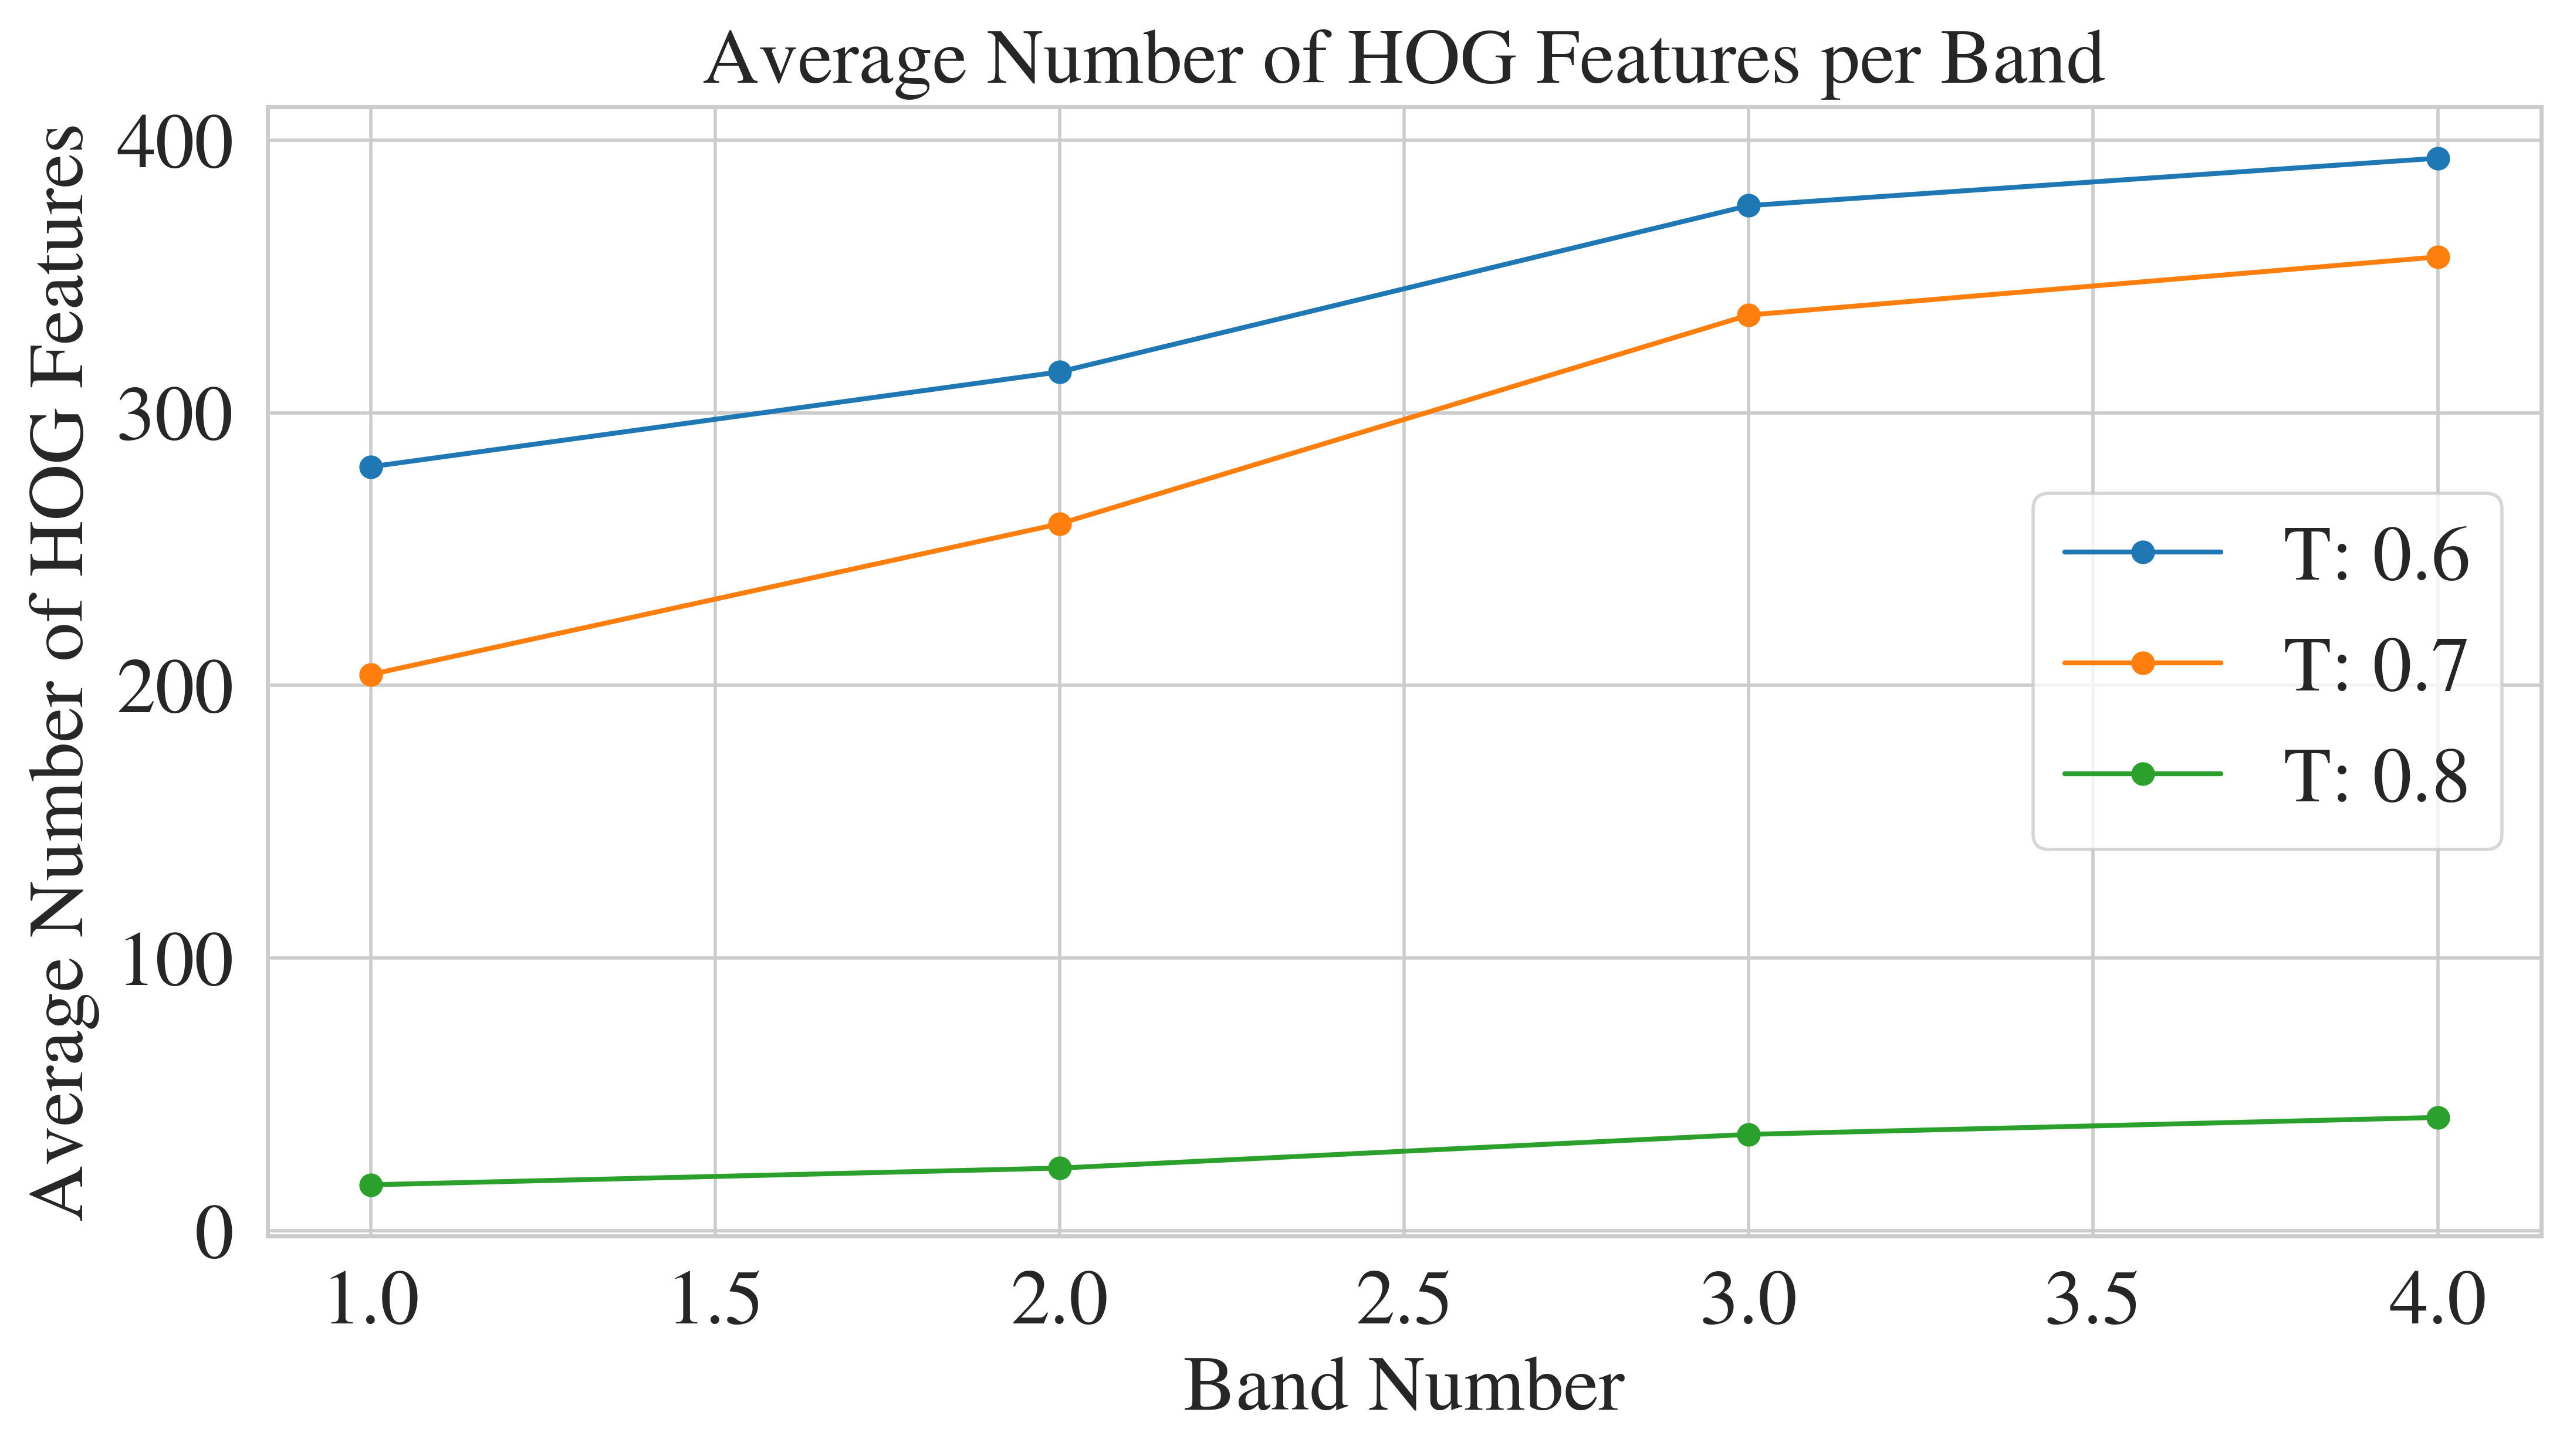

In [12]:
from pathlib import Path 
import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from style import set_style


set_style(scale_factor=1.2)

plt.figure(figsize=(10,5))


for threshold_value in [0.6, 0.7, 0.8]:
    band_num_hog = pd.read_pickle(f'sen_hog_results/band_num_hog_{threshold_value}.pkl')
    df = pd.DataFrame(band_num_hog)
    # calculate average number of HOG features per band in df
    avgs = [df[i].mean() for i in range(1,5)]

    plt.plot(range(1,5), avgs, marker='o', label=f'T: {threshold_value}')
    plt.xlabel('Band Number')
    plt.ylabel('Average Number of HOG Features')
    plt.title('Average Number of HOG Features per Band')
    plt.legend()

plt.show()
    


In [ ]:
# threshold_value = 0.75
# band_num_hog = pd.read_pickle(f'band_num_hog_{threshold_value}.pkl')
# plot_hog_features(band_num_hog)

In [ ]:
# threshold_value = 0.55
# band_num_hog = pd.read_pickle(f'band_num_hog_{threshold_value}.pkl')
# plot_hog_features(band_num_hog)